In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [3]:
df = pd.read_csv("credit_dataset_5000_enhanced_final.csv")

In [4]:
print(df.head())

   Age  Income  Coapplicant_Income  Dependents  Employ_Status   Debt  \
0   61   26587               10296           1       Employed  56824   
1   36   23236               13264           3  Self-employed  78620   
2   66   19245               32648           5       Employed  34596   
3   29   64148               19563           1       Employed  59612   
4   43  101424               49221           1     Unemployed   1523   

   PrevLDefault  CIBIL_Score  Loan_Approval  
0             1          465              0  
1             1          456              1  
2             0          572              0  
3             0          620              0  
4             0          659              0  


In [5]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [7]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Loan_Approval']),df['Loan_Approval'],
                                                test_size=0.2,random_state=42)

In [8]:
trf1 = ColumnTransformer([
    ('employ_status',
     OrdinalEncoder(categories=[['Unemployed', 'Employed', 'Self-employed']],
                     handle_unknown='use_encoded_value',
                     unknown_value=-1),
     [4])
], remainder='passthrough')

result = trf1.fit_transform(X_train)
result1=trf1.fit_transform(X_test)
Employment_train = pd.DataFrame(result, columns=trf1.get_feature_names_out())
Employment_test = pd.DataFrame(result1,columns=trf1.get_feature_names_out())
print(Employment_train)

      employ_status__Employ_Status  remainder__Age  remainder__Income  \
0                              2.0            46.0            59919.0   
1                              2.0            38.0           148339.0   
2                              1.0            65.0            86447.0   
3                              0.0            68.0            99438.0   
4                              0.0            50.0            65202.0   
...                            ...             ...                ...   
3995                           0.0            65.0            86874.0   
3996                           0.0            37.0           103570.0   
3997                           1.0            26.0            56099.0   
3998                           0.0            35.0           146002.0   
3999                           1.0            53.0            47700.0   

      remainder__Coapplicant_Income  remainder__Dependents  remainder__Debt  \
0                           66406.0         

In [9]:
Employment_train.columns = [col.replace("remainder__", "").replace("employ_status__", "") 
                            for col in Employment_train.columns]
Employment_test.columns = [col.replace("remainder__", "").replace("employ_status__", "") 
                           for col in Employment_test.columns]

In [10]:
Employment_train

,Employ_Status,Age,Income,Coapplicant_Income,Dependents,Debt,PrevLDefault,CIBIL_Score
0,2.0,46.0,59919.0,66406.0,4.0,6322.0,1.0,448.0
1,2.0,38.0,148339.0,1214.0,1.0,44037.0,0.0,569.0
2,1.0,65.0,86447.0,10673.0,2.0,2395.0,0.0,613.0
3,0.0,68.0,99438.0,85982.0,4.0,67552.0,1.0,440.0
4,0.0,50.0,65202.0,79154.0,4.0,27458.0,1.0,427.0
...,...,...,...,...,...,...,...,...
3995,0.0,65.0,86874.0,74766.0,3.0,1521.0,1.0,447.0
3996,0.0,37.0,103570.0,42480.0,0.0,75027.0,1.0,467.0
3997,1.0,26.0,56099.0,55221.0,1.0,33205.0,1.0,487.0
3998,0.0,35.0,146002.0,16101.0,3.0,73533.0,0.0,580.0


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=6,           
    min_samples_leaf=10,
    random_state=42
)
rf_model.fit(Employment_train, y_train)
y_pred = rf_model.predict(Employment_test)
print('Train accuracy:', accuracy_score(y_train, rf_model.predict(Employment_train)))
print('Test accuracy :', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Train accuracy: 0.6885
Test accuracy : 0.503

              precision    recall  f1-score   support

           0       0.52      0.46      0.49       515
           1       0.49      0.55      0.52       485

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.50      0.50      0.50      1000



In [12]:
from sklearn.model_selection import cross_val_score
model = RandomForestClassifier()
print("Training",np.mean(cross_val_score(model,Employment_train,y_train,scoring='accuracy',cv=10))*100)
print("Testing",np.mean(cross_val_score(model,Employment_test,y_test,scoring='accuracy',cv=10))*100)

Training 48.99999999999999
Testing 49.1


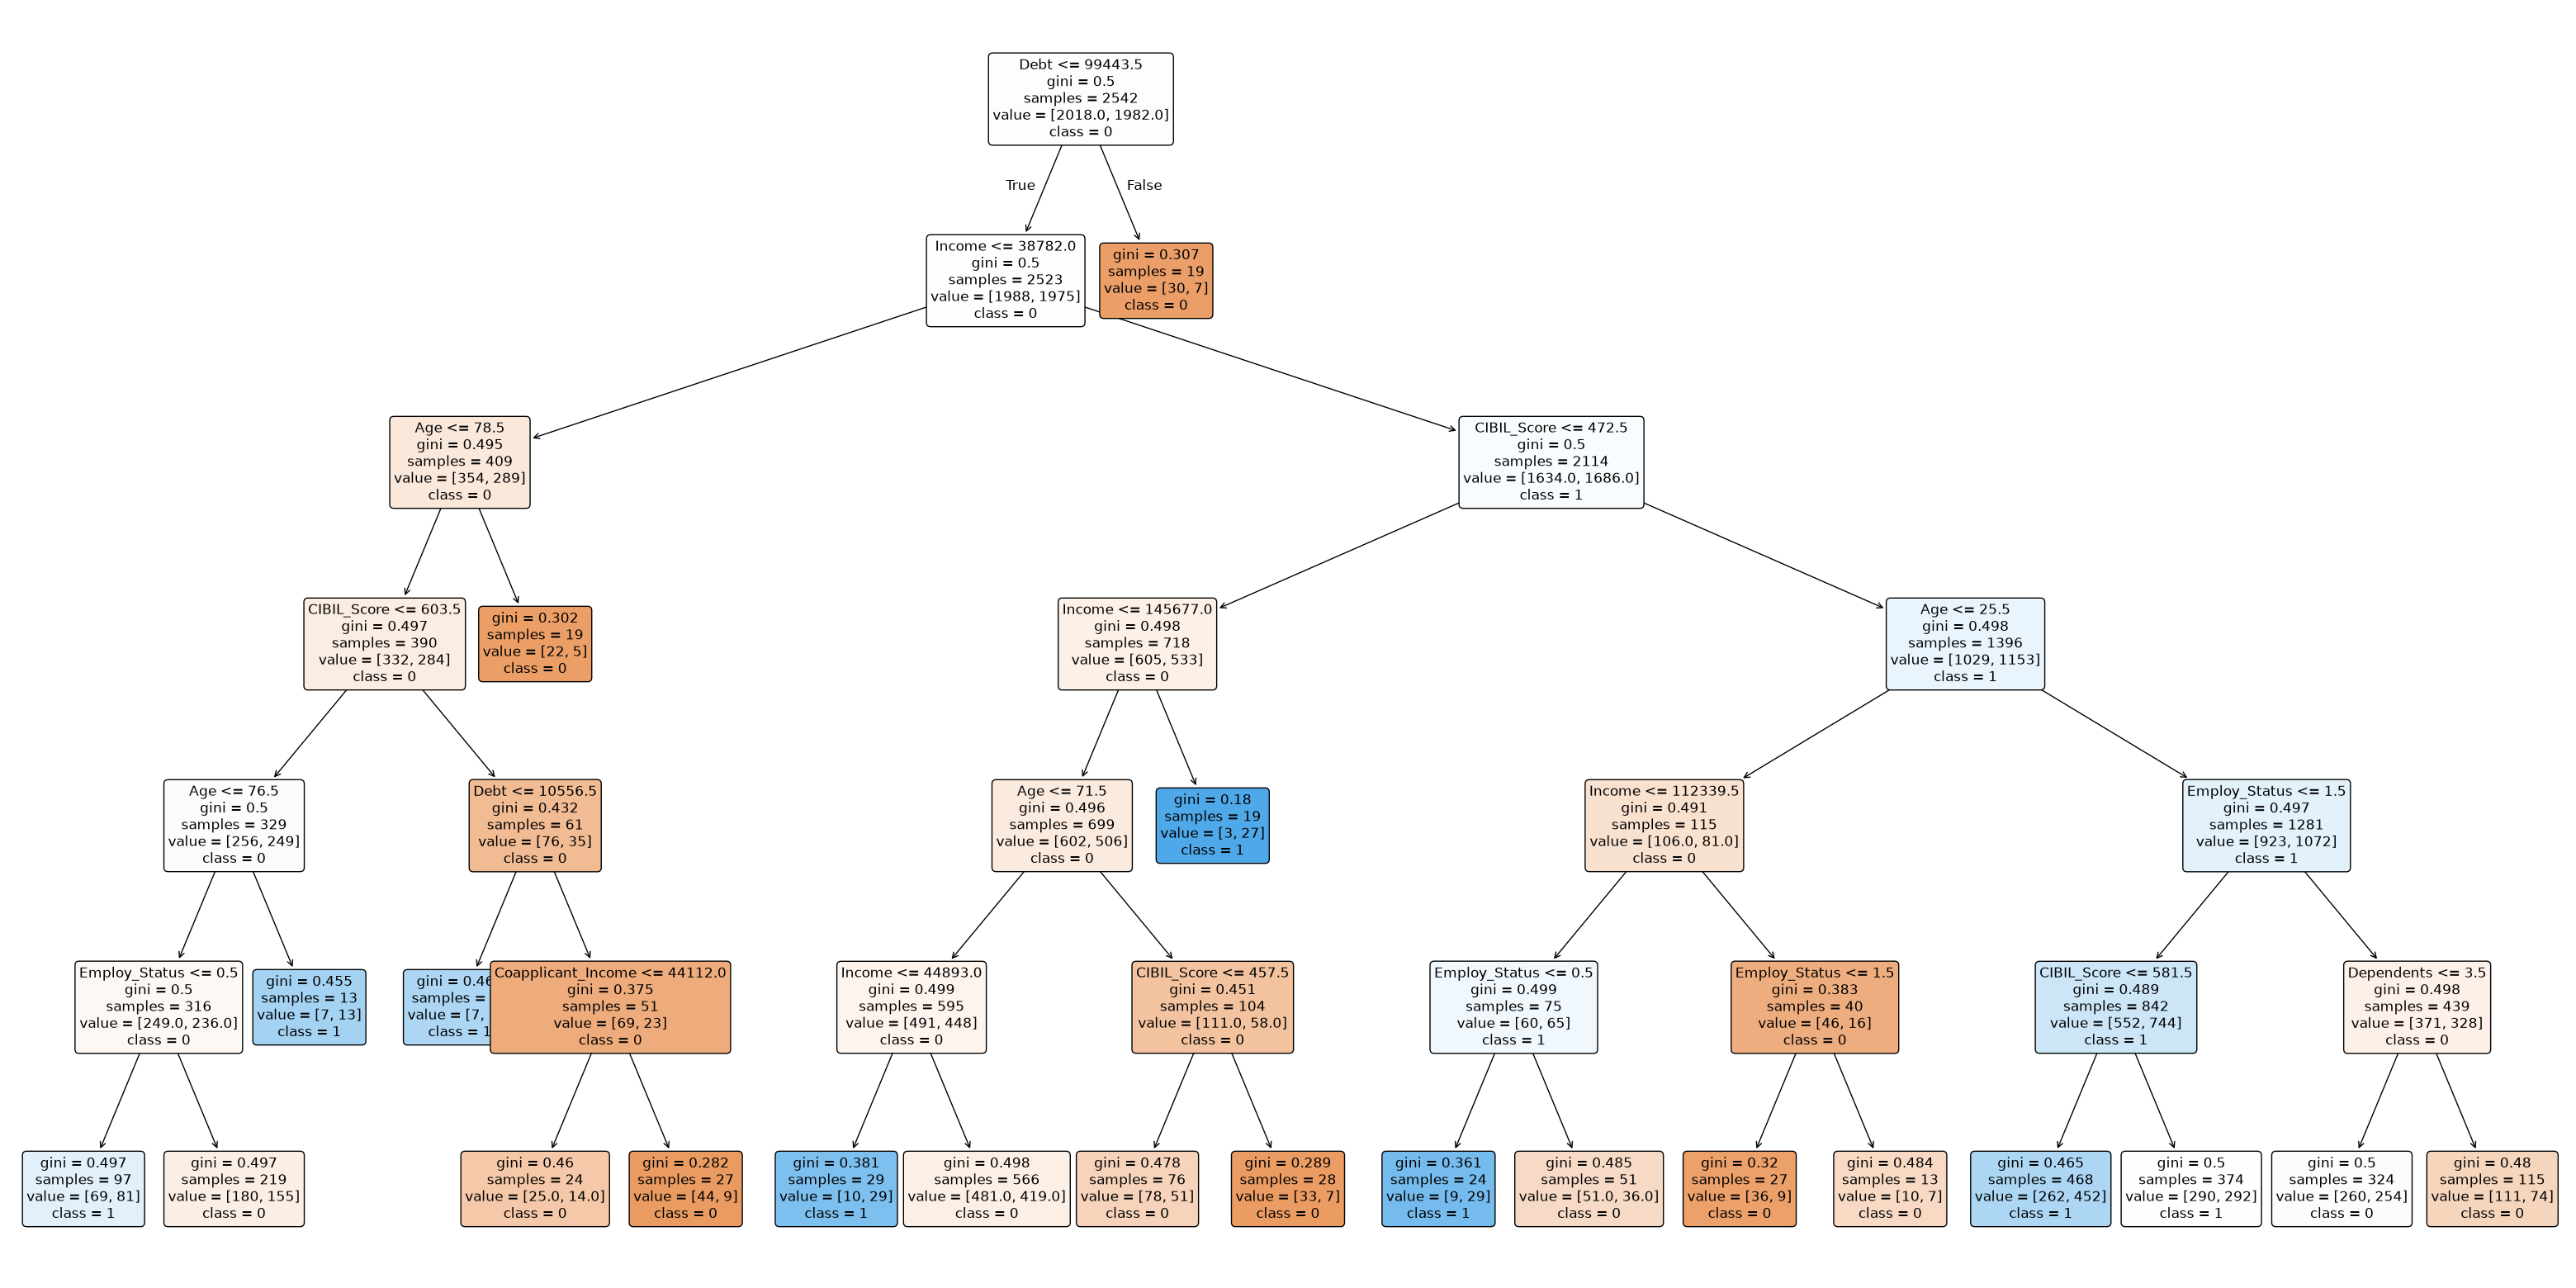

In [27]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(40, 20))
plot_tree(
    rf_model.estimators_[0],
    feature_names=Employment_train.columns,
    class_names=[str(c) for c in rf_model.classes_],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()